In [ ]:
import pandas as pd
import spacy
from spacy.cli import download
from bertopic import BERTopic
from keybert import KeyBERT

from multimodal_fin.analysis_qa_effects import (
    PipelineConfig,
    MultiCompanyRunner,
    CompanyPipeline,
    PopulationEvidenceAnalyzer,
    AggregatedEffectPlotter,
    AnswerPlotter,
    TopicModeler,
    KeywordExtractor,
    TopicLabeler,
    EmotionFeatureBuilder,
    StatsTester,
    TranscriptQALoader,
    TextPreprocessor,
    EmotionAggregator
)

/home/aacastro/env_6-1-2026/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-14 17:53:26.734339: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-14 17:53:26.784828: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-14 17:53:27.757167: I tensorflow/core/util/p

In [2]:
cfg = PipelineConfig(processed_root="/home/aacastro/mchai/processed_companies")

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

topic_model = BERTopic(language="english", min_topic_size=3, embedding_model="multi-qa-distilbert-cos-v1", verbose=False)
qa_kw_model = KeyBERT(model="all-MiniLM-L12-v2")
topic_kw_model = KeyBERT()

In [3]:
emo_agg = EmotionAggregator()
loader = TranscriptQALoader(cfg, emo_agg)
preproc = TextPreprocessor(nlp)
topic_modeler = TopicModeler(preproc, topic_model)
kw_extractor = KeywordExtractor(qa_kw_model)
topic_labeler = TopicLabeler(topic_kw_model)
feature_builder = EmotionFeatureBuilder(cfg)
stats = StatsTester(cfg)
plotter = AnswerPlotter()

In [4]:
pipeline = CompanyPipeline(
    config=cfg,
    loader=loader,
    topic_modeler=topic_modeler,
    kw_extractor=kw_extractor,
    topic_labeler=topic_labeler,
    feature_builder=feature_builder,
    stats=stats,
    plotter=plotter,
)

Loaded 181 QA pairs from 13 conferences for company KMI.
Loaded 248 QA pairs from 20 conferences for company AAPL.


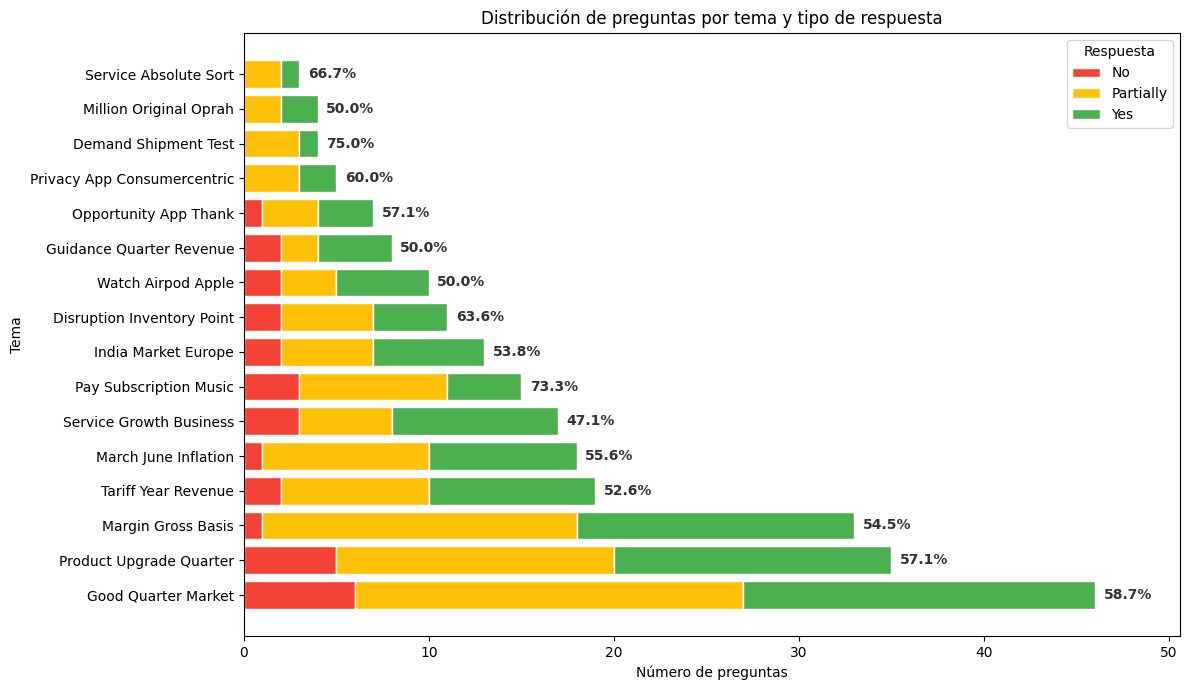

Loaded 204 QA pairs from 13 conferences for company ABNB.
Loaded 178 QA pairs from 15 conferences for company WMB.
Loaded 293 QA pairs from 17 conferences for company PSX.
Loaded 421 QA pairs from 22 conferences for company TDG.
Loaded 127 QA pairs from 9 conferences for company APD.
Loaded 116 QA pairs from 15 conferences for company AWK.
Loaded 179 QA pairs from 21 conferences for company AMZN.
Loaded 263 QA pairs from 13 conferences for company ECL.
Loaded 482 QA pairs from 21 conferences for company SYK.
Loaded 259 QA pairs from 21 conferences for company MCD.
Loaded 225 QA pairs from 22 conferences for company CMCSA.
Loaded 246 QA pairs from 21 conferences for company DHR.
Loaded 215 QA pairs from 11 conferences for company CHD.
Loaded 115 QA pairs from 9 conferences for company MDT.
Loaded 223 QA pairs from 15 conferences for company WEC.
Loaded 208 QA pairs from 19 conferences for company ACN.
Loaded 350 QA pairs from 23 conferences for company PFE.
Loaded 342 QA pairs from 24 c

In [5]:
data = pd.read_csv("../data/full_paths.csv")
companies = data["company"].unique().tolist()

runner = MultiCompanyRunner(pipeline, cfg, use_tqdm=False)
df_all = runner.run(companies, plot_company="AAPL")

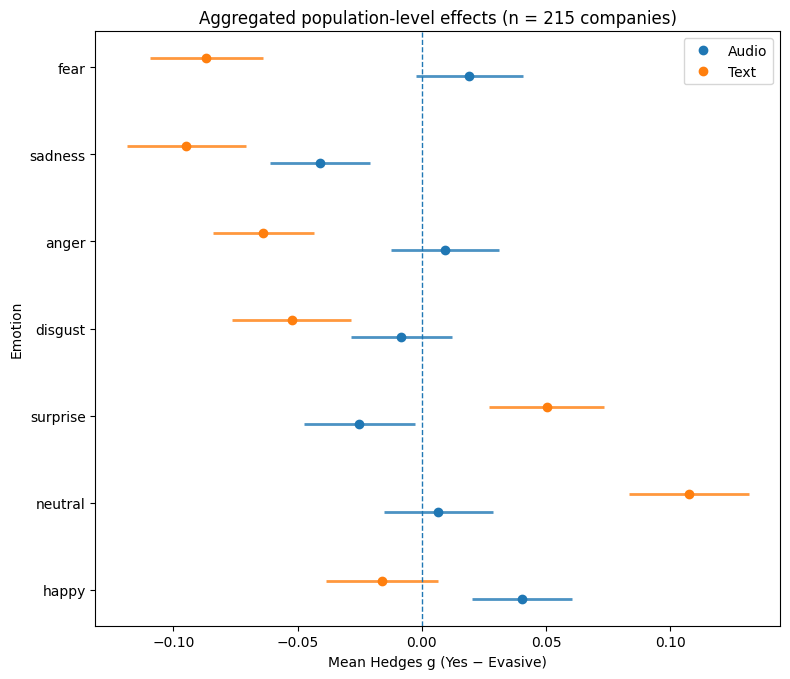

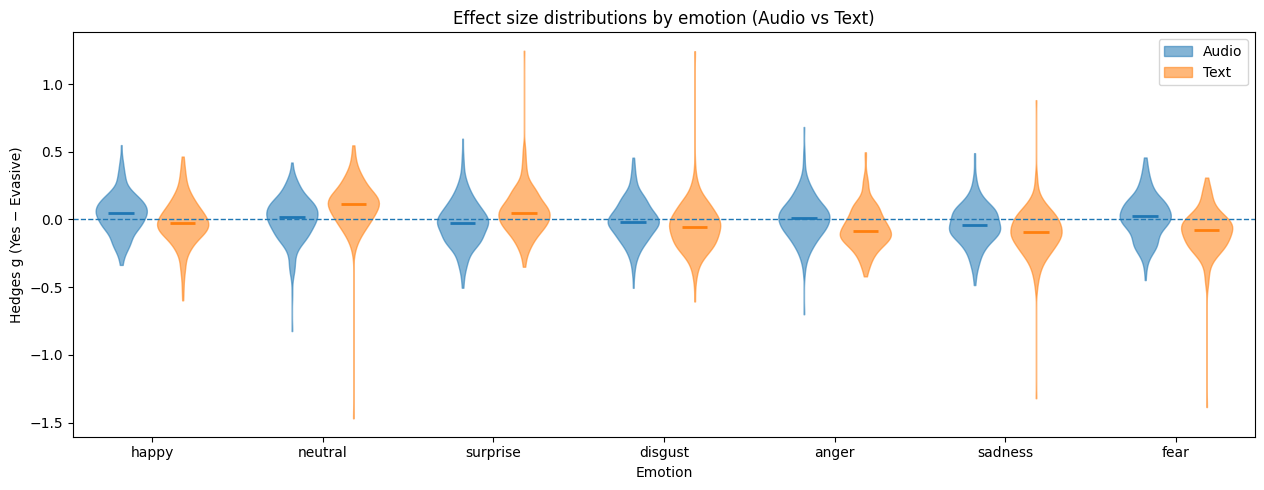

In [ ]:
evidence = PopulationEvidenceAnalyzer(cfg)
df_pop = evidence.compute_population_evidence(df_all)

plotter = AggregatedEffectPlotter(cfg)
plotter.forest_plot_aggregated_combined(df_all)
plotter.grouped_violin_by_emotion(df_all)

## Conclusions: emotions vs. response behavior (Yes vs. Evasive)

**Definition reminder**  
Effect size is Hedges g = Yes − Evasive  
- **g > 0** → emotion stronger when the question *is answered*  
- **g < 0** → emotion stronger when the question *is evaded*  
- There is population-level evidence if CI doestnt cross x=0.

The conclusions below combine:
- **Violin plots** → distribution and heterogeneity across companies  
- **Aggregated forest plot** → population-level evidence (mean + 95% CI)

---

### Sadness
- **Direction**: g < 0 (audio & text)
- **Evidence**: population-level evidence in both modalities
- **Interpretation**:  
  Evaded questions systematically show more sadness, both in how things are said (audio) and what is said (text).  
  This is the most robust emotional signal in the analysis.

---

### Anger
- **Direction**: g < 0 in text, ~0 in audio
- **Evidence**: population-level evidence only in text
- **Interpretation**:  
  Evaded answers tend to contain more anger in the textual content, but this is not clearly reflected in vocal tone.  
  This points to multimodal dissonance, not a strong global anger effect.

---

### Happy
- **Direction**: g > 0 in audio, ~0 in text
- **Evidence**: population-level evidence only in audio
- **Interpretation**:  
  When questions are answered, speakers sound slightly more positive, but this positivity is not clearly expressed in the text.

---

### Neutral
- **Direction**: g > 0 in text, ~0 in audio
- **Evidence**: clear population-level evidence in text
- **Interpretation**:  
  Direct answers are **systematically more neutral in wording**, while evasive answers deviate from neutral language.  
  This effect is semantic rather than prosodic.

---

### Fear — **secondary, text-only effect**
- **Direction**: g < 0 in text, ~0 in audio
- **Evidence**: population-level evidence only in text
- **Interpretation**:  
  Evaded answers show slightly more fear in text, but the effect is not mirrored in audio.

---

### Disgust
- **Direction**: g < 0 in text, ~0 in audio
- **Evidence**: population-level evidence only in text
- **Interpretation**:  
   Evaded answers show slightly more fear in text.

---

### Surprise
- **Direction**: g > 0 in text, g < 0 in audio
- **Evidence**: limited and not robust
- **Interpretation**:  
  Surprise does not play a central role in distinguishing response behavior.
